#EfficientNetB0 Model

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Veri Kümeleri Yükleniyor ---
Found 13420 files belonging to 14 classes.
Found 2635 files belonging to 14 classes.
Found 2638 files belonging to 14 classes.
Bulunan sınıflar: ['Dolmalik_biber_Bakteriyel_leke', 'Dolmalik_biber_healthy', 'Domates _Septoria_leaf', 'Domates_Kirmizi_orumcek', 'Domates_Yaprak_kufu', 'Patates_Alternaria_solani', 'Patates_healthy', 'domates_Alternaria_solani', 'domates_Bacterial_spot', 'domates_Phytophthora_infestans', 'domates_Yellow_Leaf__Curl_Virus', 'domates_healthy', 'domates_mosaic_virus', 'patates_Phytophthora_infestans']
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- Model Özeti ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067,505 (15.52 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- Model Eğitiliyor (50 Epoch) ---
Epoch 1/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 896s 195ms/step - accuracy: 0.6728 - loss: 1.1680 - val_accuracy: 0.9047 - val_loss: 0.3683
Epoch 2/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.9019 - loss: 0.3649 - val_accuracy: 0.9378 - val_loss: 0.2388
Epoch 3/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9197 - loss: 0.2736 - val_accuracy: 0.9374 - val_loss: 0.2162
Epoch 4/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9332 - loss: 0.2220 - val_accuracy: 0.9469 - val_loss: 0.1823
Epoch 5/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9329 - loss: 0.2125 - val_accuracy: 0.9472 - val_loss: 0.1736
Epoch 6/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9424 - loss: 0.1896 - val_accuracy: 0.9537 - val_loss: 0.1476
Epoch 7/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9465 - loss: 0.1731 - val_accuracy: 0.9586 - val_loss: 0.1408
Epoch 8/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/st

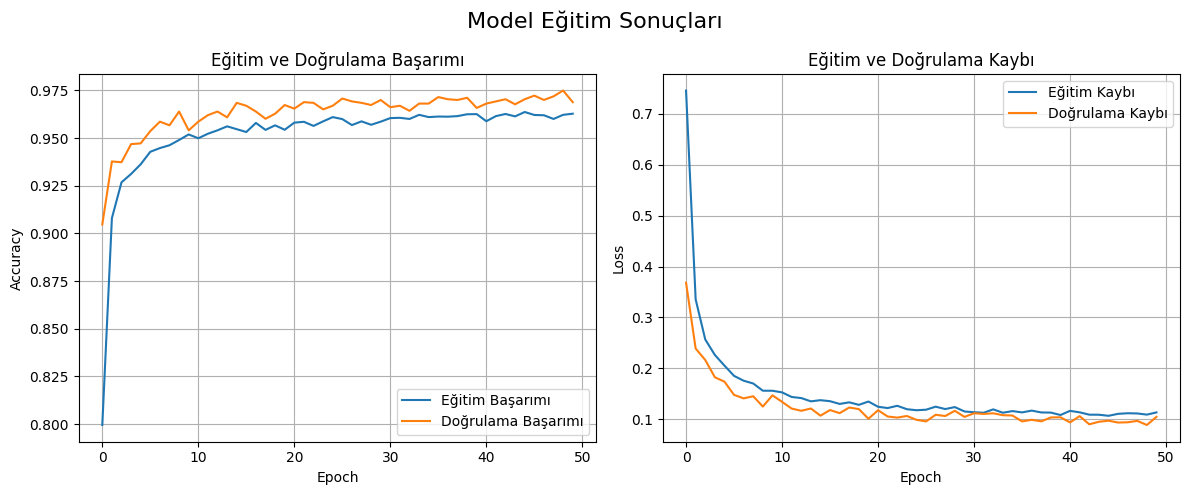


Model eğitimi ve değerlendirmesi tamamlandı.


In [ ]:
# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
import os
from google.colab import drive
drive.mount('/content/drive')


# --- Veri Seti Ayarları ---
base_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation') # Doğrulama klasör yolu
test_dir = os.path.join(base_dir, 'test')

# Görüntü boyutu, parti boyutu ve epoch sayısı gibi hiperparametreleri tanımlıyoruz.
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50

# Veri kümelerini dosya dizinlerinden yüklüyoruz.
print("--- Veri Kümeleri Yükleniyor ---")
# Eğitim veri kümesi: Eğitim dizininden görüntüleri okur.
train_dataset = image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama veri kümesi: Ayrı bir dizinden doğrulama alt kümesini alır.
validation_dataset = image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test veri kümesi: Test dizininden görüntüleri okur. Karıştırma (shuffle) devre dışı bırakılır.
test_dataset = image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Sınıf isimlerini alıyoruz ve toplam sınıf sayısını belirliyoruz.
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Bulunan sınıflar: {class_names}")

# Veri akışını optimize etmek için önbelleğe alma ve önceden getirme (prefetching) kullanıyoruz.
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# Veri artırma (data augmentation) katmanını tanımlıyoruz.
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),  # Görüntüleri yatay olarak rastgele çevirir.
    RandomRotation(0.1),       # Görüntüleri rastgele döndürür.
], name="data_augmentation")

# Modelin giriş katmanını oluşturuyoruz.
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Girdi verisine veri artırma uyguluyoruz.
x = data_augmentation(inputs)

# EfficientNetB0 gibi önceden eğitilmiş bir modeli temel alıyoruz (Transfer Learning).
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Temel modelin ağırlıklarını donduruyoruz. Eğitim sırasında ağırlıkları güncellenmeyecek.
base_model.trainable = False

# Temel modelden gelen çıktıya yeni katmanlar ekliyoruz.
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) # Ortalamayı alarak boyutluluğu azaltır.
x = Dropout(0.3)(x)             # Aşırı uydurmayı (overfitting) önlemek için nöronları rastgele kapatır.

# Çıkış katmanı: Sınıf sayısına eşit nöron içerir ve 'softmax' aktivasyonu ile olasılıkları hesaplar.
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Giriş ve çıkış katmanlarını belirterek modelimizi oluşturuyoruz.
model = Model(inputs, outputs)

# Modeli derliyoruz (compile).
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Modelin yapısını özetliyoruz.
print("\n--- Model Özeti ---")
model.summary()

# --- Model Eğitimi ---
print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

# --- Model Değerlendirmesi ---
print("\nModel test verisi üzerinde değerlendirme aşaması...")
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# --- Eğitim Sonuçlarını Görselleştirme ---
# Eğitim ve doğrulama başarımlarını ve kayıplarını grafiğe döküyoruz.
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# Başarım grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarımı')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
plt.legend(loc='lower right')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
plt.legend(loc='upper right')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Genel başlık ve düzenleme
plt.suptitle('Model Eğitim Sonuçları', fontsize=16)
plt.tight_layout()
plt.show()

print("\nModel eğitimi ve değerlendirmesi tamamlandı.")


# MobileNet V2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Veri Kümeleri Yükleniyor ---
Found 13420 files belonging to 14 classes.
Found 2635 files belonging to 14 classes.
Found 2638 files belonging to 14 classes.
Bulunan sınıflar: ['Dolmalik_biber_Bakteriyel_leke', 'Dolmalik_biber_healthy', 'Domates _Septoria_leaf', 'Domates_Kirmizi_orumcek', 'Domates_Yaprak_kufu', 'Patates_Alternaria_solani', 'Patates_healthy', 'domates_Alternaria_solani', 'domates_Bacterial_spot', 'domates_Phytophthora_infestans', 'domates_Yellow_Leaf__Curl_Virus', 'domates_healthy', 'domates_mosaic_virus', 'patates_Phytophthora_infestans']


/tmp/ipython-input-1090675710.py:91: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Model Özeti (MobileNetV2) ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,918 (8.68 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


--- Model Eğitiliyor (50 Epoch) ---
Epoch 1/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 402s 92ms/step - accuracy: 0.6505 - loss: 1.1515 - val_accuracy: 0.8638 - val_loss: 0.4041
Epoch 2/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.8826 - loss: 0.3805 - val_accuracy: 0.9017 - val_loss: 0.3043
Epoch 3/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.8940 - loss: 0.3160 - val_accuracy: 0.9173 - val_loss: 0.2566
Epoch 4/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.9032 - loss: 0.2857 - val_accuracy: 0.9047 - val_loss: 0.2850
Epoch 5/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.9117 - loss: 0.2666 - val_accuracy: 0.9226 - val_loss: 0.2425
Epoch 6/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9135 - loss: 0.2633 - val_accuracy: 0.9245 - val_loss: 0.2243
Epoch 7/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9173 - loss: 0.2413 - val_accuracy: 0.9302 - val_loss: 0.2115
Epoch 8/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/ste

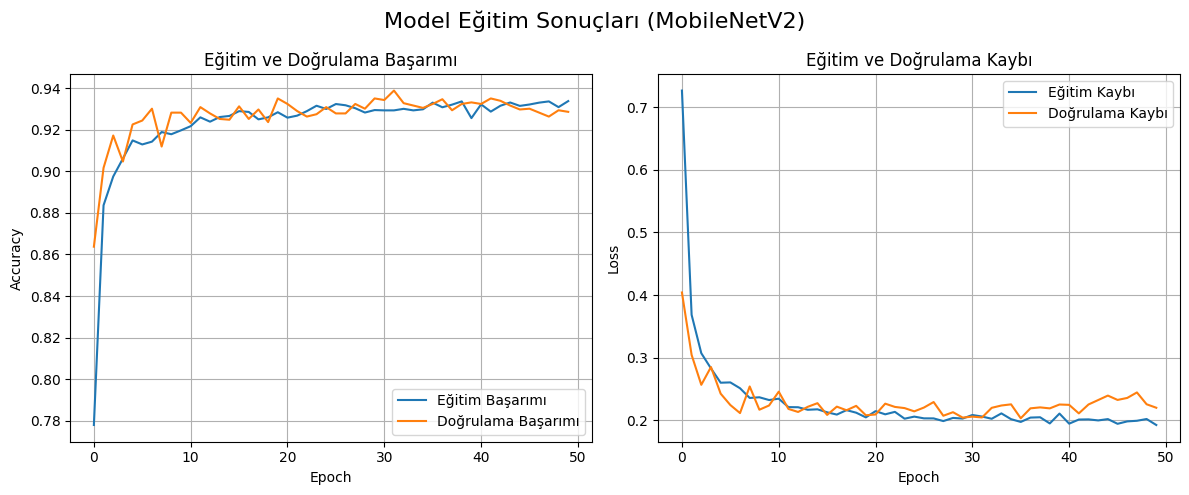


Model eğitimi ve değerlendirmesi tamamlandı.


In [ ]:
# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import os
from google.colab import drive

# Google Drive'ı Colab ortamına bağlıyoruz
drive.mount('/content/drive')


# --- Veri Seti Ayarları ---
base_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation') # Doğrulama klasör yolu
test_dir = os.path.join(base_dir, 'test')

# Görüntü boyutu, parti boyutu ve epoch sayısı gibi hiperparametreleri tanımlıyoruz.
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50

# Veri kümelerini dosya dizinlerinden yüklüyoruz.
print("--- Veri Kümeleri Yükleniyor ---")
# Eğitim veri kümesi: Eğitim dizininden görüntüleri okur.
train_dataset = image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama veri kümesi: Ayrı bir dizinden doğrulama alt kümesini alır.
validation_dataset = image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test veri kümesi: Test dizininden görüntüleri okur. Karıştırma (shuffle) devre dışı bırakılır.
test_dataset = image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Sınıf isimlerini alıyoruz ve toplam sınıf sayısını belirliyoruz.
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Bulunan sınıflar: {class_names}")

# Veri akışını optimize etmek için önbelleğe alma ve önceden getirme (prefetching) kullanıyoruz.
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# --- Model Oluşturma ve Yapılandırma ---
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
], name="data_augmentation")

# Modelin giriş katmanını oluşturuyoruz.
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Girdi verisine MobileNetV2'nin beklediği ön işlemeyi uyguluyoruz.
x = preprocess_input(inputs)

# Girdi verisine veri artırma uyguluyoruz.
x = data_augmentation(x)

# MobileNetV2 modelini temel alıyoruz (Transfer Learning).
# include_top=False: Son sınıflandırma katmanlarını dahil etme.
# weights='imagenet': ImageNet veri kümesinde eğitilmiş ağırlıkları kullan.
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Temel modelin ağırlıklarını donduruyoruz. Eğitim sırasında ağırlıkları güncellenmeyecek.
base_model.trainable = False

# Temel modelden gelen çıktıya yeni katmanlar ekliyoruz.
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

# Çıkış katmanı: Sınıf sayısına eşit nöron içerir ve 'softmax' aktivasyonu ile olasılıkları hesaplar.
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Giriş ve çıkış katmanlarını belirterek modelimizi oluşturuyoruz.
model = Model(inputs, outputs)

# Modeli derliyoruz (compile).
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Modelin yapısını özetliyoruz.
print("\n--- Model Özeti (MobileNetV2) ---")
model.summary()

# --- Model Eğitimi ---
print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

# --- Model Değerlendirmesi ---
print("\nModel test verisi üzerinde değerlendirme aşaması...")
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Eğitim ve doğrulama başarımlarını ve kayıplarını grafiğe döküyoruz.
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# Başarım grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarımı')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
plt.legend(loc='lower right')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
plt.legend(loc='upper right')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Genel başlık ve düzenleme
plt.suptitle('Model Eğitim Sonuçları (MobileNetV2)', fontsize=16)
plt.tight_layout()
plt.show()

print("\nModel eğitimi ve değerlendirmesi tamamlandı.")


# ResNet V50

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Veri Kümeleri Yükleniyor ---
Found 13420 files belonging to 14 classes.
Found 2635 files belonging to 14 classes.
Found 2638 files belonging to 14 classes.
Bulunan sınıflar: ['Dolmalik_biber_Bakteriyel_leke', 'Dolmalik_biber_healthy', 'Domates _Septoria_leaf', 'Domates_Kirmizi_orumcek', 'Domates_Yaprak_kufu', 'Patates_Alternaria_solani', 'Patates_healthy', 'domates_Alternaria_solani', 'domates_Bacterial_spot', 'domates_Phytophthora_infestans', 'domates_Yellow_Leaf__Curl_Virus', 'domates_healthy', 'domates_mosaic_virus', 'patates_Phytophthora_infestans']
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- Model Özeti (ResNet50V2) ---


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 8, 8, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │        28,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,486 (90.00 MB)

 Trainable params: 28,686 (112.05 KB)

 Non-trainable params: 23,564,800 (89.89 MB)


--- Model Eğitiliyor (50 Epoch) ---
Epoch 1/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.6588 - loss: 1.1006 - val_accuracy: 0.8664 - val_loss: 0.4079
Epoch 2/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.8796 - loss: 0.3627 - val_accuracy: 0.9104 - val_loss: 0.2853
Epoch 3/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.9084 - loss: 0.2900 - val_accuracy: 0.9093 - val_loss: 0.2681
Epoch 4/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.9073 - loss: 0.2821 - val_accuracy: 0.9290 - val_loss: 0.2339
Epoch 5/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.9112 - loss: 0.2523 - val_accuracy: 0.9283 - val_loss: 0.2258
Epoch 6/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.9152 - loss: 0.2562 - val_accuracy: 0.9321 - val_loss: 0.1987
Epoch 7/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 48s 37ms/step - accuracy: 0.9242 - loss: 0.2305 - val_accuracy: 0.9343 - val_loss: 0.2023
Epoch 8/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 48s 37ms/step

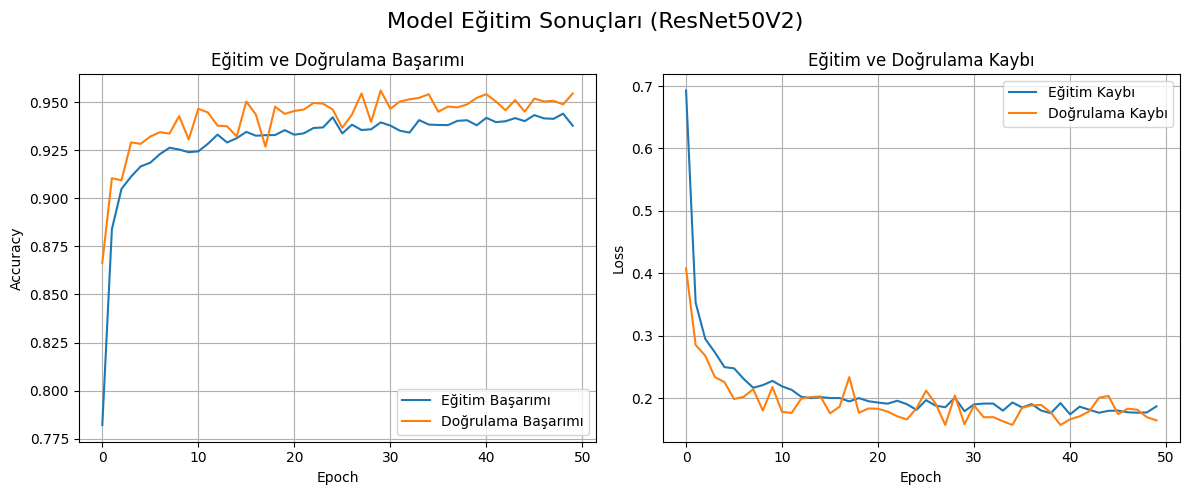


Model eğitimi ve değerlendirmesi tamamlandı.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Veri Kümeleri Yükleniyor ---
Found 13420 files belonging to 14 classes.
Found 2635 files belonging to 14 classes.
Found 2638 files belonging to 14 classes.
Bulunan sınıflar: ['Dolmalik_biber_Bakteriyel_leke', 'Dolmalik_biber_healthy', 'Domates _Septoria_leaf', 'Domates_Kirmizi_orumcek', 'Domates_Yaprak_kufu', 'Patates_Alternaria_solani', 'Patates_healthy', 'domates_Alternaria_solani', 'domates_Bacterial_spot', 'domates_Phytophthora_infestans', 'domates_Yellow_Leaf__Curl_Virus', 'domates_healthy', 'domates_mosaic_virus', 'patates_Phytophthora_infestans']

--- Model Özeti (ResNet50V2) ---


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 8, 8, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │        28,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,486 (90.00 MB)

 Trainable params: 28,686 (112.05 KB)

 Non-trainable params: 23,564,800 (89.89 MB)


--- Model Eğitiliyor (50 Epoch) ---
Epoch 1/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 57s 39ms/step - accuracy: 0.6598 - loss: 1.0807 - val_accuracy: 0.8956 - val_loss: 0.3483
Epoch 2/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step - accuracy: 0.8795 - loss: 0.3755 - val_accuracy: 0.8937 - val_loss: 0.3183
Epoch 3/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.8998 - loss: 0.3039 - val_accuracy: 0.9047 - val_loss: 0.2864
Epoch 4/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step - accuracy: 0.9086 - loss: 0.2834 - val_accuracy: 0.9317 - val_loss: 0.2307
Epoch 5/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step - accuracy: 0.9149 - loss: 0.2541 - val_accuracy: 0.9207 - val_loss: 0.2315
Epoch 6/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step - accuracy: 0.9227 - loss: 0.2309 - val_accuracy: 0.9343 - val_loss: 0.2002
Epoch 7/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 48s 36ms/step - accuracy: 0.9206 - loss: 0.2310 - val_accuracy: 0.9381 - val_loss: 0.1802
Epoch 8/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step

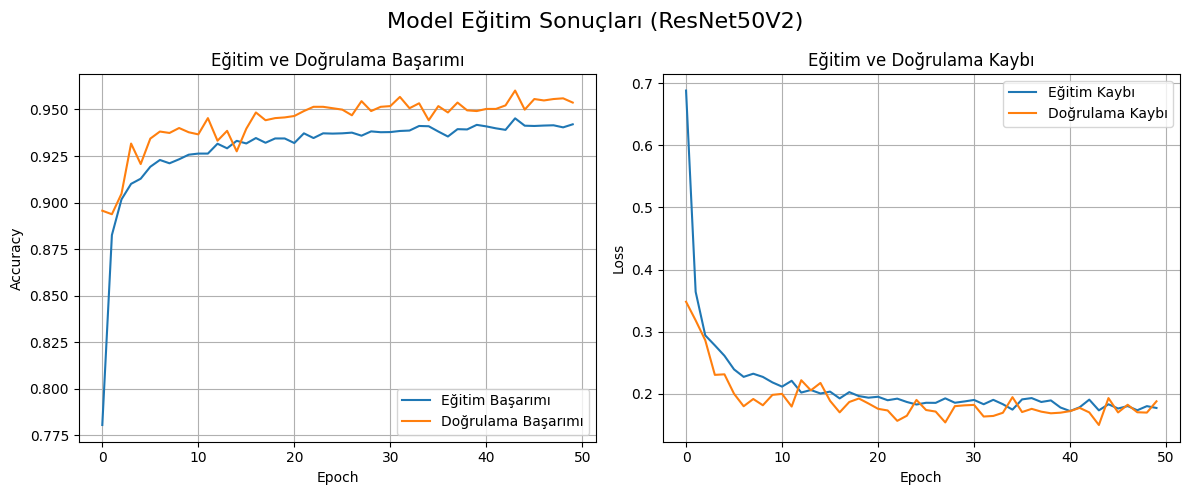


Model eğitimi ve değerlendirmesi tamamlandı.


In [ ]:
# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
# MobileNetV2 yerine ResNet50V2 ve ön işleme fonksiyonunu içe aktarıyoruz
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
import os
from google.colab import drive

def load_datasets(base_dir, img_size, batch_size):
    """!
    @brief Eğitim, doğrulama ve test veri kümelerini belirtilen dizinlerden yükler.

    Veri kümelerini TensorFlow'un `image_dataset_from_directory` fonksiyonunu
    kullanarak oluşturur ve performansı artırmak için önceden getirme (prefetch)
    mekanizmasını uygular.

    @param base_dir   Veri setinin ('train', 'validation', 'test' klasörlerini içeren) ana dizini.
    @param img_size   Görüntülerin yeniden boyutlandırılacağı boyut (yükseklik, genişlik).
    @param batch_size Eğitim sırasında kullanılacak parti büyüklüğü.
    @return train_dataset, validation_dataset, test_dataset, class_names tuple'ı.
    """
    print("--- Veri Kümeleri Yükleniyor ---")
    train_dir = os.path.join(base_dir, 'train')
    val_dir = os.path.join(base_dir, 'validation')
    test_dir = os.path.join(base_dir, 'test')

    train_dataset = image_dataset_from_directory(
        train_dir, seed=123, image_size=img_size, batch_size=batch_size)
    validation_dataset = image_dataset_from_directory(
        val_dir, seed=123, image_size=img_size, batch_size=batch_size)
    test_dataset = image_dataset_from_directory(
        test_dir, seed=123, image_size=img_size, batch_size=batch_size, shuffle=False)

    class_names = train_dataset.class_names
    print(f"Bulunan sınıflar: {class_names}")

    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
    test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

    return train_dataset, validation_dataset, test_dataset, class_names

def build_model(input_shape, num_classes):
    """!
    @brief ResNet50V2 tabanlı bir transfer öğrenme modeli oluşturur ve derler.

    Model, veri artırma, ResNet50V2 ön işleme, dondurulmuş ResNet50V2 tabanı ve
    yeni bir sınıflandırma başlığı içerir.

    @param input_shape Modelin girdi olarak alacağı görüntülerin şekli (yükseklik, genişlik, kanal).
    @param num_classes Modelin tahmin edeceği toplam sınıf sayısı.
    @return Derlenmiş Keras Modeli.
    """
    # Veri artırma (data augmentation) katmanı
    data_augmentation = tf.keras.Sequential([
        RandomFlip('horizontal'),
        RandomRotation(0.1),
    ], name="data_augmentation")

    inputs = Input(shape=input_shape)

    # ResNet50V2'nin beklediği ön işlemeyi uygula
    x = preprocess_input(inputs)
    x = data_augmentation(x)

    # ResNet50V2 modelini temel al
    base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # Temel modelin ağırlıklarını dondur

    # Yeni sınıflandırma katmanları ekle
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    # Modeli derle
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def plot_training_history(history, epochs):
    """!
    @brief Modelin eğitim ve doğrulama sonuçlarını görselleştirir.

    Başarım (accuracy) ve kayıp (loss) metrikleri için iki ayrı grafik çizer.

    @param history Modelin `fit` metodundan dönen History nesnesi.
    @param epochs  Eğitimde kullanılan toplam epoch sayısı.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(epochs)

    plt.figure(figsize=(12, 5))

    # Başarım grafiği
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Eğitim Başarımı')
    plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
    plt.legend(loc='lower right')
    plt.title('Eğitim ve Doğrulama Başarımı')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    # Kayıp grafiği
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Eğitim Kaybı')
    plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
    plt.legend(loc='upper right')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.suptitle('Model Eğitim Sonuçları (ResNet50V2)', fontsize=16)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    # Google Drive'ı Colab ortamına bağlıyoruz
    drive.mount('/content/drive')

    # --- Ayarlar ve Hiperparametreler ---
    BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
    IMG_SIZE = (256, 256)
    BATCH_SIZE = 16
    EPOCHS = 50

    # 1. Veri Kümelerini Yükle
    train_ds, val_ds, test_ds, class_names = load_datasets(BASE_DIR, IMG_SIZE, BATCH_SIZE)

    # 2. Modeli Oluştur
    NUM_CLASSES = len(class_names)
    INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)
    model = build_model(INPUT_SHAPE, NUM_CLASSES)

    print("\n--- Model Özeti (ResNet50V2) ---")
    model.summary()

    # 3. Modeli Eğit
    print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

    # 4. Modeli Değerlendir
    print("\nModel test verisi üzerinde değerlendirme aşaması...")
    test_loss, test_accuracy = model.evaluate(test_ds)
    print(f"\nTest kaybı: {test_loss:.4f}")
    print(f"Test başarımı: {test_accuracy:.4f}")

    # 5. Sonuçları Görselleştir
    plot_training_history(history, EPOCHS)

    print("\nModel eğitimi ve değerlendirmesi tamamlandı.")
# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
# MobileNetV2 yerine ResNet50V2 ve ön işleme fonksiyonunu içe aktarıyoruz
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
import os
from google.colab import drive

def load_datasets(base_dir, img_size, batch_size):
    """!
    @brief Eğitim, doğrulama ve test veri kümelerini belirtilen dizinlerden yükler.

    Veri kümelerini TensorFlow'un `image_dataset_from_directory` fonksiyonunu
    kullanarak oluşturur ve performansı artırmak için önceden getirme (prefetch)
    mekanizmasını uygular.

    @param base_dir   Veri setinin ('train', 'validation', 'test' klasörlerini içeren) ana dizini.
    @param img_size   Görüntülerin yeniden boyutlandırılacağı boyut (yükseklik, genişlik).
    @param batch_size Eğitim sırasında kullanılacak parti büyüklüğü.
    @return train_dataset, validation_dataset, test_dataset, class_names tuple'ı.
    """
    print("--- Veri Kümeleri Yükleniyor ---")
    train_dir = os.path.join(base_dir, 'train')
    val_dir = os.path.join(base_dir, 'validation')
    test_dir = os.path.join(base_dir, 'test')

    train_dataset = image_dataset_from_directory(
        train_dir, seed=123, image_size=img_size, batch_size=batch_size)
    validation_dataset = image_dataset_from_directory(
        val_dir, seed=123, image_size=img_size, batch_size=batch_size)
    test_dataset = image_dataset_from_directory(
        test_dir, seed=123, image_size=img_size, batch_size=batch_size, shuffle=False)

    class_names = train_dataset.class_names
    print(f"Bulunan sınıflar: {class_names}")

    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
    test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

    return train_dataset, validation_dataset, test_dataset, class_names

def build_model(input_shape, num_classes):
    """!
    @brief ResNet50V2 tabanlı bir transfer öğrenme modeli oluşturur ve derler.

    Model, veri artırma, ResNet50V2 ön işleme, dondurulmuş ResNet50V2 tabanı ve
    yeni bir sınıflandırma başlığı içerir.

    @param input_shape Modelin girdi olarak alacağı görüntülerin şekli (yükseklik, genişlik, kanal).
    @param num_classes Modelin tahmin edeceği toplam sınıf sayısı.
    @return Derlenmiş Keras Modeli.
    """
    # Veri artırma (data augmentation) katmanı
    data_augmentation = tf.keras.Sequential([
        RandomFlip('horizontal'),
        RandomRotation(0.1),
    ], name="data_augmentation")

    inputs = Input(shape=input_shape)

    # ResNet50V2'nin beklediği ön işlemeyi uygula
    x = preprocess_input(inputs)
    x = data_augmentation(x)

    # ResNet50V2 modelini temel al
    base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # Temel modelin ağırlıklarını dondur

    # Yeni sınıflandırma katmanları ekle
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    # Modeli derle
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def plot_training_history(history, epochs):
    """!
    @brief Modelin eğitim ve doğrulama sonuçlarını görselleştirir.

    Başarım (accuracy) ve kayıp (loss) metrikleri için iki ayrı grafik çizer.

    @param history Modelin `fit` metodundan dönen History nesnesi.
    @param epochs  Eğitimde kullanılan toplam epoch sayısı.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(epochs)

    plt.figure(figsize=(12, 5))

    # Başarım grafiği
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Eğitim Başarımı')
    plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
    plt.legend(loc='lower right')
    plt.title('Eğitim ve Doğrulama Başarımı')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    # Kayıp grafiği
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Eğitim Kaybı')
    plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
    plt.legend(loc='upper right')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.suptitle('Model Eğitim Sonuçları (ResNet50V2)', fontsize=16)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    # Google Drive'ı Colab ortamına bağlıyoruz
    drive.mount('/content/drive')

    # --- Ayarlar ve Hiperparametreler ---
    BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
    IMG_SIZE = (256, 256)
    BATCH_SIZE = 16
    EPOCHS = 50

    # 1. Veri Kümelerini Yükle
    train_ds, val_ds, test_ds, class_names = load_datasets(BASE_DIR, IMG_SIZE, BATCH_SIZE)

    # 2. Modeli Oluştur
    NUM_CLASSES = len(class_names)
    INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)
    model = build_model(INPUT_SHAPE, NUM_CLASSES)

    print("\n--- Model Özeti (ResNet50V2) ---")
    model.summary()

    # 3. Modeli Eğit
    print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

    # 4. Modeli Değerlendir
    print("\nModel test verisi üzerinde değerlendirme aşaması...")
    test_loss, test_accuracy = model.evaluate(test_ds)
    print(f"\nTest kaybı: {test_loss:.4f}")
    print(f"Test başarımı: {test_accuracy:.4f}")

    # 5. Sonuçları Görselleştir
    plot_training_history(history, EPOCHS)

    print("\nModel eğitimi ve değerlendirmesi tamamlandı.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Veri Kümeleri Yükleniyor ---
Found 13420 files belonging to 14 classes.
Found 2635 files belonging to 14 classes.
Found 2638 files belonging to 14 classes.
Bulunan sınıflar: ['Dolmalik_biber_Bakteriyel_leke', 'Dolmalik_biber_healthy', 'Domates _Septoria_leaf', 'Domates_Kirmizi_orumcek', 'Domates_Yaprak_kufu', 'Patates_Alternaria_solani', 'Patates_healthy', 'domates_Alternaria_solani', 'domates_Bacterial_spot', 'domates_Phytophthora_infestans', 'domates_Yellow_Leaf__Curl_Virus', 'domates_healthy', 'domates_mosaic_virus', 'patates_Phytophthora_infestans']

--- Model Özeti ---


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067,505 (15.52 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- Model Eğitiliyor (50 Epoch) ---
Epoch 1/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.6579 - loss: 1.1860 - val_accuracy: 0.9112 - val_loss: 0.3436
Epoch 2/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.8959 - loss: 0.3741 - val_accuracy: 0.9378 - val_loss: 0.2382
Epoch 3/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.9222 - loss: 0.2739 - val_accuracy: 0.9412 - val_loss: 0.2033
Epoch 4/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9345 - loss: 0.2283 - val_accuracy: 0.9427 - val_loss: 0.1905
Epoch 5/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9348 - loss: 0.2172 - val_accuracy: 0.9491 - val_loss: 0.1715
Epoch 6/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9438 - loss: 0.1844 - val_accuracy: 0.9545 - val_loss: 0.1544
Epoch 7/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.9508 - loss: 0.1685 - val_accuracy: 0.9598 - val_loss: 0.1378
Epoch 8/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step


Test loss: 0.0829
Test Accuracy: 0.9719

--- Model .h5 formatında kaydediliyor ---
Model başarıyla '/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/saved_models/plant_health_model.h5' adresine kaydedildi.

--- Model SavedModel formatında dışa aktarılıyor ---
Saved artifact at '/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/saved_models/plant_health_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_247')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  138410420041872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138410420042064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138410648948944: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138410648949712: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138410420042256: TensorSpec(shape=(), dtype=tf

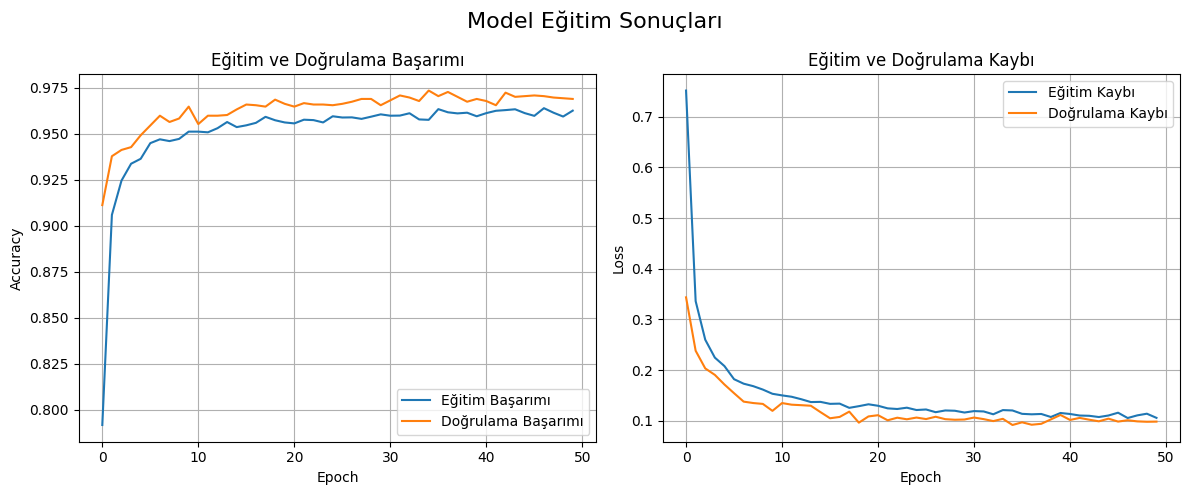


Model eğitimi, farklı formatlarda kaydı ve değerlendirmesi tamamlandı.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Veri Kümeleri Yükleniyor ---
Found 13420 files belonging to 14 classes.
Found 2635 files belonging to 14 classes.
Found 2638 files belonging to 14 classes.
Bulunan sınıflar: ['Dolmalik_biber_Bakteriyel_leke', 'Dolmalik_biber_healthy', 'Domates _Septoria_leaf', 'Domates_Kirmizi_orumcek', 'Domates_Yaprak_kufu', 'Patates_Alternaria_solani', 'Patates_healthy', 'domates_Alternaria_solani', 'domates_Bacterial_spot', 'domates_Phytophthora_infestans', 'domates_Yellow_Leaf__Curl_Virus', 'domates_healthy', 'domates_mosaic_virus', 'patates_Phytophthora_infestans']

--- Model Özeti ---


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067,505 (15.52 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- Model Eğitiliyor (50 Epoch) ---
Epoch 1/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.6658 - loss: 1.1924 - val_accuracy: 0.9161 - val_loss: 0.3426
Epoch 2/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9016 - loss: 0.3604 - val_accuracy: 0.9400 - val_loss: 0.2342
Epoch 3/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9206 - loss: 0.2741 - val_accuracy: 0.9408 - val_loss: 0.2164
Epoch 4/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.9306 - loss: 0.2337 - val_accuracy: 0.9419 - val_loss: 0.1980
Epoch 5/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.9370 - loss: 0.2038 - val_accuracy: 0.9503 - val_loss: 0.1640
Epoch 6/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9432 - loss: 0.1903 - val_accuracy: 0.9537 - val_loss: 0.1513
Epoch 7/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9475 - loss: 0.1722 - val_accuracy: 0.9586 - val_loss: 0.1400
Epoch 8/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step


Test loss: 0.0785
Test Accuracy: 0.9723

--- Model .h5 formatında kaydediliyor ---
Model başarıyla '/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/saved_models/plant_health_model.h5' adresine kaydedildi.

--- Model SavedModel formatında dışa aktarılıyor ---
Saved artifact at '/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/saved_models/plant_health_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_494')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  138410420373264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138410420373072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138410624020176: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138410624020944: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138410420376144: TensorSpec(shape=(), dtype=tf

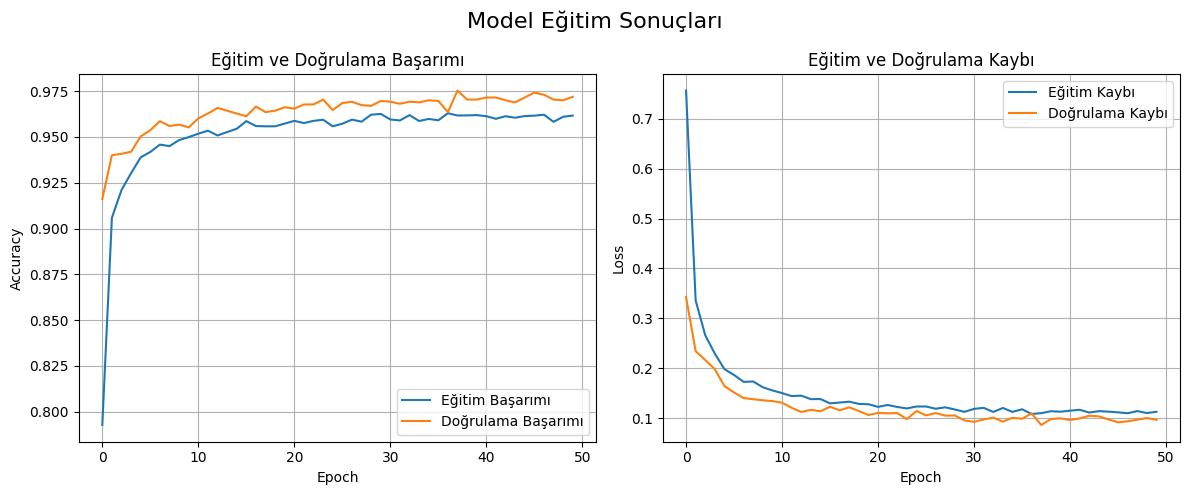


Model eğitimi, farklı formatlarda kaydı ve değerlendirmesi tamamlandı.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Veri Kümeleri Yükleniyor ---
Found 13420 files belonging to 14 classes.
Found 2635 files belonging to 14 classes.
Found 2638 files belonging to 14 classes.
Bulunan sınıflar: ['Dolmalik_biber_Bakteriyel_leke', 'Dolmalik_biber_healthy', 'Domates _Septoria_leaf', 'Domates_Kirmizi_orumcek', 'Domates_Yaprak_kufu', 'Patates_Alternaria_solani', 'Patates_healthy', 'domates_Alternaria_solani', 'domates_Bacterial_spot', 'domates_Phytophthora_infestans', 'domates_Yellow_Leaf__Curl_Virus', 'domates_healthy', 'domates_mosaic_virus', 'patates_Phytophthora_infestans']

--- Model Özeti ---


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067,505 (15.52 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- Model Eğitiliyor (50 Epoch) ---
Epoch 1/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.6748 - loss: 1.1646 - val_accuracy: 0.9085 - val_loss: 0.3577
Epoch 2/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.8964 - loss: 0.3729 - val_accuracy: 0.9336 - val_loss: 0.2458
Epoch 3/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9225 - loss: 0.2666 - val_accuracy: 0.9442 - val_loss: 0.1975
Epoch 4/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.9329 - loss: 0.2224 - val_accuracy: 0.9476 - val_loss: 0.1745
Epoch 5/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.9390 - loss: 0.2059 - val_accuracy: 0.9526 - val_loss: 0.1648
Epoch 6/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9450 - loss: 0.1832 - val_accuracy: 0.9560 - val_loss: 0.1478
Epoch 7/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.9468 - loss: 0.1740 - val_accuracy: 0.9560 - val_loss: 0.1418
Epoch 8/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step

KeyboardInterrupt: 

In [ ]:
# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
import os
from google.colab import drive
drive.mount('/content/drive')


# --- Veri Seti Ayarları ---
# Veri setinizin bulunduğu ana dizin yolunu belirtin.
# Bu yolu, Google Drive'ınızdaki gerçek konuma göre ayarladığınızdan emin olun.
base_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation') # Doğrulama klasör yolu
test_dir = os.path.join(base_dir, 'test')

# Görüntü boyutu, parti boyutu ve epoch sayısı gibi hiperparametreleri tanımlıyoruz.
# Eğer 512x512 boyutu hala bellek sorununa yol açarsa, 256x256 veya 224x224 gibi
# daha küçük bir değere düşürmeyi düşünebilirsiniz.
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50

# Veri kümelerini dosya dizinlerinden yüklüyoruz.
print("--- Veri Kümeleri Yükleniyor ---")
# Eğitim veri kümesi: Eğitim dizininden görüntüleri okur.
train_dataset = image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama veri kümesi: Ayrı bir dizinden doğrulama alt kümesini alır.
validation_dataset = image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test veri kümesi: Test dizininden görüntüleri okur. Karıştırma (shuffle) devre dışı bırakılır.
test_dataset = image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Sınıf isimlerini alıyoruz ve toplam sınıf sayısını belirliyoruz.
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Bulunan sınıflar: {class_names}")

# Veri akışını optimize etmek için önbelleğe alma ve önceden getirme (prefetching) kullanıyoruz.
AUTOTUNE = tf.data.AUTOTUNE

# NOT: .cache() komutu, tüm veri setini belleğe yükler ve yüksek RAM kullanımına neden olabilir.
# Bu nedenle, bu komutu kaldırdık.
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# --- Model Oluşturma ve Yapılandırma ---
# Veri artırma (data augmentation) katmanını tanımlıyoruz.
# Bu, modelin genelleme yeteneğini artırmak için eğitim verisine rastgele dönüşümler uygular.
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),  # Görüntüleri yatay olarak rastgele çevirir.
    RandomRotation(0.1),       # Görüntüleri rastgele döndürür.
], name="data_augmentation")

# Modelin giriş katmanını oluşturuyoruz.
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Girdi verisine veri artırma uyguluyoruz.
x = data_augmentation(inputs)

# EfficientNetB0 gibi önceden eğitilmiş bir modeli temel alıyoruz (Transfer Learning).
# include_top=False: Son sınıflandırma katmanlarını dahil etme.
# weights='imagenet': ImageNet veri kümesinde eğitilmiş ağırlıkları kullan.
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Temel modelin ağırlıklarını donduruyoruz. Eğitim sırasında ağırlıkları güncellenmeyecek.
base_model.trainable = False

# Temel modelden gelen çıktıya yeni katmanlar ekliyoruz.
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) # Ortalamayı alarak boyutluluğu azaltır.
x = Dropout(0.3)(x)             # Aşırı uydurmayı (overfitting) önlemek için nöronları rastgele kapatır.

# Çıkış katmanı: Sınıf sayısına eşit nöron içerir ve 'softmax' aktivasyonu ile olasılıkları hesaplar.
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Giriş ve çıkış katmanlarını belirterek modelimizi oluşturuyoruz.
model = Model(inputs, outputs)

# Modeli derliyoruz (compile).
# Optimizer: Adam, öğrenme hızını dinamik olarak ayarlar.
# Loss: sparse_categorical_crossentropy, çok sınıflı sınıflandırma için uygundur.
# Metrics: accuracy, modelin performansını ölçmek için kullanılır.
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Modelin yapısını özetliyoruz.
print("\n--- Model Özeti ---")
model.summary()

# --- Model Eğitimi ---
print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

# --- Model Değerlendirmesi ---
print("\nModel test verisi üzerinde değerlendirme aşaması...")
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# --- Modeli Farklı Formatlarda Kaydetme ---

# Kayıt işlemleri için ana dizini belirliyoruz
save_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/saved_models"
os.makedirs(save_dir, exist_ok=True)

# 1. H5 formatında kaydetme
print("\n--- Model .h5 formatında kaydediliyor ---")
h5_path = os.path.join(save_dir, "plant_health_model.h5")
model.save(h5_path)
print(f"Model başarıyla '{h5_path}' adresine kaydedildi.")

# 2. TFLite ve Web için temel olacak SavedModel formatında dışa aktarma
print("\n--- Model SavedModel formatında dışa aktarılıyor ---")
saved_model_path = os.path.join(save_dir, "plant_health_saved_model")
model.export(saved_model_path)
print(f"Model başarıyla '{saved_model_path}' adresine dışa aktarıldı.")

# 3. TensorFlow Lite (.tflite) formatına dönüştürme
print("\n--- Model .tflite formatına dönüştürülüyor ---")
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
    tflite_model = converter.convert()
    tflite_path = os.path.join(save_dir, "plant_health_model.tflite")
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"Model başarıyla '{tflite_path}' adresine kaydedildi.")
except Exception as e:
    print(f"TFLite dönüşümü sırasında hata oluştu: {e}")

# 4. Web (TensorFlow.js) formatı için talimatlar
print("\n--- Web (TensorFlow.js) için dönüştürme talimatları ---")
print("Modeli TensorFlow.js formatına dönüştürmek için aşağıdaki komutu terminalde veya yeni bir Colab hücresinde çalıştırın:")
print("Önce tensorflowjs kütüphanesini kurun: !pip install tensorflowjs")
tfjs_output_path = os.path.join(save_dir, "plant_health_tfjs_model")
print(f"\n!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model '{saved_model_path}' '{tfjs_output_path}'")


# --- Eğitim Sonuçlarını Görselleştirme ---
# Eğitim ve doğrulama başarımlarını ve kayıplarını grafiğe döküyoruz.
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# Başarım grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarımı')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
plt.legend(loc='lower right')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
plt.legend(loc='upper right')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Genel başlık ve düzenleme
plt.suptitle('Model Eğitim Sonuçları', fontsize=16)
plt.tight_layout()
plt.show()

print("\nModel eğitimi, farklı formatlarda kaydı ve değerlendirmesi tamamlandı.")

# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
import os
from google.colab import drive
drive.mount('/content/drive')


# --- Veri Seti Ayarları ---
# Veri setinizin bulunduğu ana dizin yolunu belirtin.
# Bu yolu, Google Drive'ınızdaki gerçek konuma göre ayarladığınızdan emin olun.
base_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation') # Doğrulama klasör yolu
test_dir = os.path.join(base_dir, 'test')

# Görüntü boyutu, parti boyutu ve epoch sayısı gibi hiperparametreleri tanımlıyoruz.
# Eğer 512x512 boyutu hala bellek sorununa yol açarsa, 256x256 veya 224x224 gibi
# daha küçük bir değere düşürmeyi düşünebilirsiniz.
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50

# Veri kümelerini dosya dizinlerinden yüklüyoruz.
print("--- Veri Kümeleri Yükleniyor ---")
# Eğitim veri kümesi: Eğitim dizininden görüntüleri okur.
train_dataset = image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama veri kümesi: Ayrı bir dizinden doğrulama alt kümesini alır.
validation_dataset = image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test veri kümesi: Test dizininden görüntüleri okur. Karıştırma (shuffle) devre dışı bırakılır.
test_dataset = image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Sınıf isimlerini alıyoruz ve toplam sınıf sayısını belirliyoruz.
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Bulunan sınıflar: {class_names}")

# Veri akışını optimize etmek için önbelleğe alma ve önceden getirme (prefetching) kullanıyoruz.
AUTOTUNE = tf.data.AUTOTUNE

# NOT: .cache() komutu, tüm veri setini belleğe yükler ve yüksek RAM kullanımına neden olabilir.
# Bu nedenle, bu komutu kaldırdık.
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# --- Model Oluşturma ve Yapılandırma ---
# Veri artırma (data augmentation) katmanını tanımlıyoruz.
# Bu, modelin genelleme yeteneğini artırmak için eğitim verisine rastgele dönüşümler uygular.
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),  # Görüntüleri yatay olarak rastgele çevirir.
    RandomRotation(0.1),       # Görüntüleri rastgele döndürür.
], name="data_augmentation")

# Modelin giriş katmanını oluşturuyoruz.
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Girdi verisine veri artırma uyguluyoruz.
x = data_augmentation(inputs)

# EfficientNetB0 gibi önceden eğitilmiş bir modeli temel alıyoruz (Transfer Learning).
# include_top=False: Son sınıflandırma katmanlarını dahil etme.
# weights='imagenet': ImageNet veri kümesinde eğitilmiş ağırlıkları kullan.
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Temel modelin ağırlıklarını donduruyoruz. Eğitim sırasında ağırlıkları güncellenmeyecek.
base_model.trainable = False

# Temel modelden gelen çıktıya yeni katmanlar ekliyoruz.
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) # Ortalamayı alarak boyutluluğu azaltır.
x = Dropout(0.3)(x)             # Aşırı uydurmayı (overfitting) önlemek için nöronları rastgele kapatır.

# Çıkış katmanı: Sınıf sayısına eşit nöron içerir ve 'softmax' aktivasyonu ile olasılıkları hesaplar.
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Giriş ve çıkış katmanlarını belirterek modelimizi oluşturuyoruz.
model = Model(inputs, outputs)

# Modeli derliyoruz (compile).
# Optimizer: Adam, öğrenme hızını dinamik olarak ayarlar.
# Loss: sparse_categorical_crossentropy, çok sınıflı sınıflandırma için uygundur.
# Metrics: accuracy, modelin performansını ölçmek için kullanılır.
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Modelin yapısını özetliyoruz.
print("\n--- Model Özeti ---")
model.summary()

# --- Model Eğitimi ---
print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

# --- Model Değerlendirmesi ---
print("\nModel test verisi üzerinde değerlendirme aşaması...")
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# --- Modeli Farklı Formatlarda Kaydetme ---

# Kayıt işlemleri için ana dizini belirliyoruz
save_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/saved_models"
os.makedirs(save_dir, exist_ok=True)

# 1. H5 formatında kaydetme
print("\n--- Model .h5 formatında kaydediliyor ---")
h5_path = os.path.join(save_dir, "plant_health_model.h5")
model.save(h5_path)
print(f"Model başarıyla '{h5_path}' adresine kaydedildi.")

# 2. TFLite ve Web için temel olacak SavedModel formatında dışa aktarma
print("\n--- Model SavedModel formatında dışa aktarılıyor ---")
saved_model_path = os.path.join(save_dir, "plant_health_saved_model")
model.export(saved_model_path)
print(f"Model başarıyla '{saved_model_path}' adresine dışa aktarıldı.")

# 3. TensorFlow Lite (.tflite) formatına dönüştürme
print("\n--- Model .tflite formatına dönüştürülüyor ---")
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
    tflite_model = converter.convert()
    tflite_path = os.path.join(save_dir, "plant_health_model.tflite")
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"Model başarıyla '{tflite_path}' adresine kaydedildi.")
except Exception as e:
    print(f"TFLite dönüşümü sırasında hata oluştu: {e}")

# 4. Web (TensorFlow.js) formatı için talimatlar
print("\n--- Web (TensorFlow.js) için dönüştürme talimatları ---")
print("Modeli TensorFlow.js formatına dönüştürmek için aşağıdaki komutu terminalde veya yeni bir Colab hücresinde çalıştırın:")
print("Önce tensorflowjs kütüphanesini kurun: !pip install tensorflowjs")
tfjs_output_path = os.path.join(save_dir, "plant_health_tfjs_model")
print(f"\n!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model '{saved_model_path}' '{tfjs_output_path}'")


# --- Eğitim Sonuçlarını Görselleştirme ---
# Eğitim ve doğrulama başarımlarını ve kayıplarını grafiğe döküyoruz.
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# Başarım grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarımı')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
plt.legend(loc='lower right')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
plt.legend(loc='upper right')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Genel başlık ve düzenleme
plt.suptitle('Model Eğitim Sonuçları', fontsize=16)
plt.tight_layout()
plt.show()

print("\nModel eğitimi, farklı formatlarda kaydı ve değerlendirmesi tamamlandı.")

# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
import os
from google.colab import drive
drive.mount('/content/drive')


# --- Veri Seti Ayarları ---
# Veri setinizin bulunduğu ana dizin yolunu belirtin.
# Bu yolu, Google Drive'ınızdaki gerçek konuma göre ayarladığınızdan emin olun.
base_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation') # Doğrulama klasör yolu
test_dir = os.path.join(base_dir, 'test')

# Görüntü boyutu, parti boyutu ve epoch sayısı gibi hiperparametreleri tanımlıyoruz.
# Eğer 512x512 boyutu hala bellek sorununa yol açarsa, 256x256 veya 224x224 gibi
# daha küçük bir değere düşürmeyi düşünebilirsiniz.
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50

# Veri kümelerini dosya dizinlerinden yüklüyoruz.
print("--- Veri Kümeleri Yükleniyor ---")
# Eğitim veri kümesi: Eğitim dizininden görüntüleri okur.
train_dataset = image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama veri kümesi: Ayrı bir dizinden doğrulama alt kümesini alır.
validation_dataset = image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test veri kümesi: Test dizininden görüntüleri okur. Karıştırma (shuffle) devre dışı bırakılır.
test_dataset = image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Sınıf isimlerini alıyoruz ve toplam sınıf sayısını belirliyoruz.
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Bulunan sınıflar: {class_names}")

# Veri akışını optimize etmek için önbelleğe alma ve önceden getirme (prefetching) kullanıyoruz.
AUTOTUNE = tf.data.AUTOTUNE

# NOT: .cache() komutu, tüm veri setini belleğe yükler ve yüksek RAM kullanımına neden olabilir.
# Bu nedenle, bu komutu kaldırdık.
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# --- Model Oluşturma ve Yapılandırma ---
# Veri artırma (data augmentation) katmanını tanımlıyoruz.
# Bu, modelin genelleme yeteneğini artırmak için eğitim verisine rastgele dönüşümler uygular.
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),  # Görüntüleri yatay olarak rastgele çevirir.
    RandomRotation(0.1),       # Görüntüleri rastgele döndürür.
], name="data_augmentation")

# Modelin giriş katmanını oluşturuyoruz.
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Girdi verisine veri artırma uyguluyoruz.
x = data_augmentation(inputs)

# EfficientNetB0 gibi önceden eğitilmiş bir modeli temel alıyoruz (Transfer Learning).
# include_top=False: Son sınıflandırma katmanlarını dahil etme.
# weights='imagenet': ImageNet veri kümesinde eğitilmiş ağırlıkları kullan.
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Temel modelin ağırlıklarını donduruyoruz. Eğitim sırasında ağırlıkları güncellenmeyecek.
base_model.trainable = False

# Temel modelden gelen çıktıya yeni katmanlar ekliyoruz.
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) # Ortalamayı alarak boyutluluğu azaltır.
x = Dropout(0.3)(x)             # Aşırı uydurmayı (overfitting) önlemek için nöronları rastgele kapatır.

# Çıkış katmanı: Sınıf sayısına eşit nöron içerir ve 'softmax' aktivasyonu ile olasılıkları hesaplar.
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Giriş ve çıkış katmanlarını belirterek modelimizi oluşturuyoruz.
model = Model(inputs, outputs)

# Modeli derliyoruz (compile).
# Optimizer: Adam, öğrenme hızını dinamik olarak ayarlar.
# Loss: sparse_categorical_crossentropy, çok sınıflı sınıflandırma için uygundur.
# Metrics: accuracy, modelin performansını ölçmek için kullanılır.
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Modelin yapısını özetliyoruz.
print("\n--- Model Özeti ---")
model.summary()

# --- Model Eğitimi ---
print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

# --- Model Değerlendirmesi ---
print("\nModel test verisi üzerinde değerlendirme aşaması...")
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# --- Modeli Farklı Formatlarda Kaydetme ---

# Kayıt işlemleri için ana dizini belirliyoruz
save_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/saved_models"
os.makedirs(save_dir, exist_ok=True)

# 1. H5 formatında kaydetme
print("\n--- Model .h5 formatında kaydediliyor ---")
h5_path = os.path.join(save_dir, "plant_health_model.h5")
model.save(h5_path)
print(f"Model başarıyla '{h5_path}' adresine kaydedildi.")

# 2. TFLite ve Web için temel olacak SavedModel formatında dışa aktarma
print("\n--- Model SavedModel formatında dışa aktarılıyor ---")
saved_model_path = os.path.join(save_dir, "plant_health_saved_model")
model.export(saved_model_path)
print(f"Model başarıyla '{saved_model_path}' adresine dışa aktarıldı.")

# 3. TensorFlow Lite (.tflite) formatına dönüştürme
print("\n--- Model .tflite formatına dönüştürülüyor ---")
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
    tflite_model = converter.convert()
    tflite_path = os.path.join(save_dir, "plant_health_model.tflite")
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"Model başarıyla '{tflite_path}' adresine kaydedildi.")
except Exception as e:
    print(f"TFLite dönüşümü sırasında hata oluştu: {e}")

# 4. Web (TensorFlow.js) formatı için talimatlar
print("\n--- Web (TensorFlow.js) için dönüştürme talimatları ---")
print("Modeli TensorFlow.js formatına dönüştürmek için aşağıdaki komutu terminalde veya yeni bir Colab hücresinde çalıştırın:")
print("Önce tensorflowjs kütüphanesini kurun: !pip install tensorflowjs")
tfjs_output_path = os.path.join(save_dir, "plant_health_tfjs_model")
print(f"\n!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model '{saved_model_path}' '{tfjs_output_path}'")


# --- Eğitim Sonuçlarını Görselleştirme ---
# Eğitim ve doğrulama başarımlarını ve kayıplarını grafiğe döküyoruz.
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# Başarım grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarımı')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
plt.legend(loc='lower right')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
plt.legend(loc='upper right')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Genel başlık ve düzenleme
plt.suptitle('Model Eğitim Sonuçları', fontsize=16)
plt.tight_layout()
plt.show()

print("\nModel eğitimi, farklı formatlarda kaydı ve değerlendirmesi tamamlandı.")

# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
import os
from google.colab import drive
drive.mount('/content/drive')


# --- Veri Seti Ayarları ---
# Veri setinizin bulunduğu ana dizin yolunu belirtin.
# Bu yolu, Google Drive'ınızdaki gerçek konuma göre ayarladığınızdan emin olun.
base_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation') # Doğrulama klasör yolu
test_dir = os.path.join(base_dir, 'test')

# Görüntü boyutu, parti boyutu ve epoch sayısı gibi hiperparametreleri tanımlıyoruz.
# Eğer 512x512 boyutu hala bellek sorununa yol açarsa, 256x256 veya 224x224 gibi
# daha küçük bir değere düşürmeyi düşünebilirsiniz.
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50

# Veri kümelerini dosya dizinlerinden yüklüyoruz.
print("--- Veri Kümeleri Yükleniyor ---")
# Eğitim veri kümesi: Eğitim dizininden görüntüleri okur.
train_dataset = image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama veri kümesi: Ayrı bir dizinden doğrulama alt kümesini alır.
validation_dataset = image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test veri kümesi: Test dizininden görüntüleri okur. Karıştırma (shuffle) devre dışı bırakılır.
test_dataset = image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Sınıf isimlerini alıyoruz ve toplam sınıf sayısını belirliyoruz.
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Bulunan sınıflar: {class_names}")

# Veri akışını optimize etmek için önbelleğe alma ve önceden getirme (prefetching) kullanıyoruz.
AUTOTUNE = tf.data.AUTOTUNE

# NOT: .cache() komutu, tüm veri setini belleğe yükler ve yüksek RAM kullanımına neden olabilir.
# Bu nedenle, bu komutu kaldırdık.
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# --- Model Oluşturma ve Yapılandırma ---
# Veri artırma (data augmentation) katmanını tanımlıyoruz.
# Bu, modelin genelleme yeteneğini artırmak için eğitim verisine rastgele dönüşümler uygular.
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),  # Görüntüleri yatay olarak rastgele çevirir.
    RandomRotation(0.1),       # Görüntüleri rastgele döndürür.
], name="data_augmentation")

# Modelin giriş katmanını oluşturuyoruz.
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Girdi verisine veri artırma uyguluyoruz.
x = data_augmentation(inputs)

# EfficientNetB0 gibi önceden eğitilmiş bir modeli temel alıyoruz (Transfer Learning).
# include_top=False: Son sınıflandırma katmanlarını dahil etme.
# weights='imagenet': ImageNet veri kümesinde eğitilmiş ağırlıkları kullan.
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Temel modelin ağırlıklarını donduruyoruz. Eğitim sırasında ağırlıkları güncellenmeyecek.
base_model.trainable = False

# Temel modelden gelen çıktıya yeni katmanlar ekliyoruz.
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x) # Ortalamayı alarak boyutluluğu azaltır.
x = Dropout(0.3)(x)             # Aşırı uydurmayı (overfitting) önlemek için nöronları rastgele kapatır.

# Çıkış katmanı: Sınıf sayısına eşit nöron içerir ve 'softmax' aktivasyonu ile olasılıkları hesaplar.
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Giriş ve çıkış katmanlarını belirterek modelimizi oluşturuyoruz.
model = Model(inputs, outputs)

# Modeli derliyoruz (compile).
# Optimizer: Adam, öğrenme hızını dinamik olarak ayarlar.
# Loss: sparse_categorical_crossentropy, çok sınıflı sınıflandırma için uygundur.
# Metrics: accuracy, modelin performansını ölçmek için kullanılır.
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Modelin yapısını özetliyoruz.
print("\n--- Model Özeti ---")
model.summary()

# --- Model Eğitimi ---
print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

# --- Model Değerlendirmesi ---
print("\nModel test verisi üzerinde değerlendirme aşaması...")
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# --- Modeli Farklı Formatlarda Kaydetme ---

# Kayıt işlemleri için ana dizini belirliyoruz
save_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/saved_models"
os.makedirs(save_dir, exist_ok=True)

# 1. H5 formatında kaydetme
print("\n--- Model .h5 formatında kaydediliyor ---")
h5_path = os.path.join(save_dir, "plant_health_model.h5")
model.save(h5_path)
print(f"Model başarıyla '{h5_path}' adresine kaydedildi.")

# 2. TFLite ve Web için temel olacak SavedModel formatında dışa aktarma
print("\n--- Model SavedModel formatında dışa aktarılıyor ---")
saved_model_path = os.path.join(save_dir, "plant_health_saved_model")
model.export(saved_model_path)
print(f"Model başarıyla '{saved_model_path}' adresine dışa aktarıldı.")

# 3. TensorFlow Lite (.tflite) formatına dönüştürme
print("\n--- Model .tflite formatına dönüştürülüyor ---")
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
    tflite_model = converter.convert()
    tflite_path = os.path.join(save_dir, "plant_health_model.tflite")
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"Model başarıyla '{tflite_path}' adresine kaydedildi.")
except Exception as e:
    print(f"TFLite dönüşümü sırasında hata oluştu: {e}")

# 4. Web (TensorFlow.js) formatı için talimatlar
print("\n--- Web (TensorFlow.js) için dönüştürme talimatları ---")
print("Modeli TensorFlow.js formatına dönüştürmek için aşağıdaki komutu terminalde veya yeni bir Colab hücresinde çalıştırın:")
print("Önce tensorflowjs kütüphanesini kurun: !pip install tensorflowjs")
tfjs_output_path = os.path.join(save_dir, "plant_health_tfjs_model")
print(f"\n!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model '{saved_model_path}' '{tfjs_output_path}'")


# --- Eğitim Sonuçlarını Görselleştirme ---
# Eğitim ve doğrulama başarımlarını ve kayıplarını grafiğe döküyoruz.
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# Başarım grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarımı')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
plt.legend(loc='lower right')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Kayıp grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
plt.legend(loc='upper right')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Genel başlık ve düzenleme
plt.suptitle('Model Eğitim Sonuçları', fontsize=16)
plt.tight_layout()
plt.show()

print("\nModel eğitimi, farklı formatlarda kaydı ve değerlendirmesi tamamlandı.")



In [ ]:
# Gerekli kütüphaneleri içe aktarıyoruz
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
import os
import json # Sınıf isimlerini kaydetmek için eklendi

# Google Drive bağlantısını kuruyoruz (Colab için)
# Eğer lokalde çalışıyorsanız bu adımı atlayabilirsiniz.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Drive bağlandıktan sonra base_dir'i kendi dosya yolunuza göre güncelleyin.
    base_dir = "/content/drive/MyDrive/Colab Notebooks/yaprak sağlığı tahmin etme/dataset_/PlantVillage_"
except ImportError:
    # Lokal bir ortamda çalışıyorsanız, base_dir'i buraya yazın.
    base_dir = "path/to/your/dataset/PlantVillage_"


# --- Veri Seti Ayarları ---
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Hiperparametreler
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 50 # Demo için epoch sayısını düşürebilirsiniz, örn: 10

# Veri kümelerini dosya dizinlerinden yüklüyoruz.
print("--- Veri Kümeleri Yükleniyor ---")
train_dataset = image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Sınıf isimlerini alıyoruz ve toplam sınıf sayısını belirliyoruz.
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Bulunan {NUM_CLASSES} sınıf: {class_names}")

# --- YENİ: Sınıf isimlerini web uygulamasında kullanmak için JSON dosyasına kaydediyoruz. ---
print("Sınıf isimleri 'class_names.json' dosyasına kaydediliyor...")
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

# Veri akışını optimize etmek için önbelleğe alma ve önceden getirme (prefetching) kullanıyoruz.
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# --- Model Oluşturma ve Yapılandırma ---
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
], name="data_augmentation")

inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Model Özeti ---")
model.summary()

# --- Model Eğitimi ---
print(f"\n--- Model Eğitiliyor ({EPOCHS} Epoch) ---")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

print("\n--- Model TensorFlow Lite'a dönüştürme ---")

import tensorflow as tf
import numpy as np

# Önce modeli H5 formatında kaydet
h5_model_path = '/content/drive/MyDrive/plant_disease_model_temp.h5'
model.save(h5_model_path)
print(f"Model H5 formatında kaydedildi: {h5_model_path}")

# TFLite converter oluştur
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# ÖNEMLİ: Eski versiyonla uyumluluk için optimizasyonları KAPATIN
# converter.optimizations = []  # Boş bırak veya yorum satırına al

# Eski TFLite runtime'ları için uyumlu hale getir
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS  # Sadece temel operasyonlar
]

# Modeli dönüştür
try:
    tflite_model = converter.convert()
    print("✓ Model başarıyla dönüştürüldü")
except Exception as e:
    print(f"⚠ Dönüştürme hatası: {e}")
    print("Optimizasyonsuz tekrar deneniyor...")
    converter.optimizations = []
    tflite_model = converter.convert()

# TFLite modelini kaydet
tflite_model_path = '/content/drive/MyDrive/plant_disease_model.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"✓ TFLite modeli kaydedildi: {tflite_model_path}")
print(f"✓ Model boyutu: {len(tflite_model) / 1024 / 1024:.2f} MB")

# Test et: Modelin çıktısını kontrol et
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\n--- Model Detayları ---")
print(f"Input shape: {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")
print(f"Input dtype: {input_details[0]['dtype']}")
print(f"Output dtype: {output_details[0]['dtype']}")

# Test görüntüsü oluştur (random)
test_input = np.random.rand(1, 256, 256, 3).astype(np.float32) * 255.0

interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
test_output = interpreter.get_tensor(output_details[0]['index'])

print(f"\nTest çıktısı (ilk 5 sınıf): {test_output[0][:5]}")
print(f"Tüm çıktılar: {test_output[0]}")
print(f"Çıktı toplamı: {np.sum(test_output[0]):.6f}")
print(f"En yüksek değer: {np.max(test_output[0]):.6f}")
print(f"En düşük değer: {np.min(test_output[0]):.6f}")

# Softmax kontrolü
if abs(np.sum(test_output[0]) - 1.0) < 0.01:
    print("\n✓ BAŞARILI: Softmax uygulanmış! (Toplam ≈ 1.0)")
    softmax_included = True
else:
    print("\n⚠ UYARI: Softmax uygulanmamış!")
    print("  Model çıktıları logit formatında (softmax Flutter'da uygulanacak)")
    softmax_included = False

# Sınıf isimlerini kaydet
import json
labels_path = '/content/drive/MyDrive/plant_disease_labels.json'
with open(labels_path, 'w') as f:
    json.dump(class_names, f)

# Model konfigürasyonunu kaydet
config_path = '/content/drive/MyDrive/model_config.json'
with open(config_path, 'w') as f:
    json.dump({
        'softmax_included': softmax_included,
        'num_classes': len(class_names),
        'input_size': 256
    }, f)

print(f"\n✓ Sınıf isimleri kaydedildi: {labels_path}")
print(f"✓ Model config kaydedildi: {config_path}")
print(f"\n{'='*50}")
print("SONUÇ:")
if softmax_included:
    print("✓ Model softmax içeriyor - Flutter'da ek işlem gerekmez")
else:
    print("⚠ Model softmax içermiyor - Flutter'da softmax uygulanacak")
print(f"{'='*50}")
# Eğitim sonuçlarını görselleştirme (opsiyonel, sunucu için gerekli değil)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarımı')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarımı')
plt.legend(loc='lower right')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
plt.legend(loc='upper right')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.suptitle('Model Eğitim Sonuçları', fontsize=16)
plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Veri Kümeleri Yükleniyor ---
Found 13420 files belonging to 14 classes.
Found 2635 files belonging to 14 classes.
Found 2638 files belonging to 14 classes.
Bulunan 14 sınıf: ['Dolmalik_biber_Bakteriyel_leke', 'Dolmalik_biber_healthy', 'Domates _Septoria_leaf', 'Domates_Kirmizi_orumcek', 'Domates_Yaprak_kufu', 'Patates_Alternaria_solani', 'Patates_healthy', 'domates_Alternaria_solani', 'domates_Bacterial_spot', 'domates_Phytophthora_infestans', 'domates_Yellow_Leaf__Curl_Virus', 'domates_healthy', 'domates_mosaic_virus', 'patates_Phytophthora_infestans']
Sınıf isimleri 'class_names.json' dosyasına kaydediliyor...


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model('/content/drive/MyDrive/plant_disease_model1.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
n
converter.target_spec.supported_ops = [
  tf.lite.OpsSet.TFLITE_BUILTINS, # Standart TFLite operasyonlarını etkinleştir
  tf.lite.OpsSet.SELECT_TF_OPS    # Gerekli TensorFlow operasyonlarını etkinleştir
]

tflite_model = converter.convert()

save_path = '/content/drive/MyDrive/plant_disease_model_v2.tflite'
with open(save_path, 'wb') as f:
  f.write(tflite_model)

print(f"Model başarıyla 'Select TF Ops' ile dönüştürüldü ve şu yola kaydedildi:\n{save_path}")


Saved artifact at '/tmp/tmpmsvuhgje'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  136218583696016: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136218583697936: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136218583698128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136218583697360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136218583695440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136218583698896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136218583699472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136218583696976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136218583696592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136218583699280: TensorSpec(shape=(), dtype=tf.resource, name=None